<a href="https://colab.research.google.com/github/jeromenazario/mlr-ai-spending-sklearn/blob/main/MLR_AI_Tool_Spending_FINALS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression Model — Predicting Monthly AI Tool Spending
**Name:** Jerome Nazario

---

### Topic Overview
**Dependent Variable:** `monthly_ai_spending_usd` — the amount (in USD) a person spends monthly on AI tools and subscriptions (e.g., ChatGPT Plus, Midjourney, Notion AI, GitHub Copilot, etc.)

**Independent Variables:**
| Variable | Description | Unit |
|---|---|---|
| `num_ai_tools` | Number of AI tool subscriptions | count |
| `daily_usage_hours` | Average hours per day using AI tools | hours |
| `monthly_income_usd` | Individual's monthly income | USD |
| `tech_experience_years` | Years of experience in a tech-related field | years |

**Hypothesis:** People who use more AI tools, spend more hours using them, earn higher incomes, and have more tech experience are expected to spend more on AI tool subscriptions monthly.


---
## Step 1: Import Required Libraries and Define the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ── Load dataset from GitHub raw CSV ──────────────────────────────────────
GITHUB_RAW_URL = "https://raw.githubusercontent.com/jeromenazario/mlr-ai-spending-sklearn/refs/heads/main/ai_tool_spending_dataset.csv"

df = pd.read_csv(GITHUB_RAW_URL)

print(f' Dataset loaded successfully!')
print(f'    Source : {GITHUB_RAW_URL}')
print(f'    Shape  : {df.shape[0]} rows × {df.shape[1]} columns')
print('\nColumn names and data types:')
print(df.dtypes)
print('\nFirst 10 rows:')
df.head(10)

 Dataset loaded successfully!
    Source : https://raw.githubusercontent.com/jeromenazario/mlr-ai-spending-sklearn/refs/heads/main/ai_tool_spending_dataset.csv
    Shape  : 60 rows × 5 columns

Column names and data types:
num_ai_tools                 int64
daily_usage_hours          float64
monthly_income_usd           int64
tech_experience_years        int64
monthly_ai_spending_usd    float64
dtype: object

First 10 rows:


,num_ai_tools,daily_usage_hours,monthly_income_usd,tech_experience_years,monthly_ai_spending_usd
0,7,4.8,8168,5,100.07
1,4,0.7,11414,4,92.94
2,8,6.8,4657,19,150.67
3,5,3.9,7415,1,77.42
4,7,3.5,11289,5,91.86
5,10,7.4,4193,10,142.94
6,3,6.0,5127,15,120.96
7,7,2.9,11055,15,136.09
8,8,4.8,11673,0,120.47
9,5,4.4,6950,8,96.88


**Why this step matters:** Importing the necessary libraries (NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn) and building a structured DataFrame are the essential foundation of any machine learning workflow. Without a clean, well-organized dataset, the model has nothing meaningful to learn from.

---
## Step 2: Prepare Variables for Modeling

In [ ]:
# Define feature matrix X and target vector y
X = df[['num_ai_tools', 'daily_usage_hours', 'monthly_income_usd', 'tech_experience_years']]
y = df['monthly_ai_spending_usd']

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Feature matrix X (first 5 rows):')
print(X.head())
print(f'\nTarget variable y (first 5 values):\n{y.head()}')
print(f'\nTraining set size : {X_train.shape[0]} rows')
print(f'Test set size     : {X_test.shape[0]} rows')

Feature matrix X (first 5 rows):
   num_ai_tools  daily_usage_hours  monthly_income_usd  tech_experience_years
0             7                4.8                8168                      5
1             4                0.7               11414                      4
2             8                6.8                4657                     19
3             5                3.9                7415                      1
4             7                3.5               11289                      5

Target variable y (first 5 values):
0    100.07
1     92.94
2    150.67
3     77.42
4     91.86
Name: monthly_ai_spending_usd, dtype: float64

Training set size : 48 rows
Test set size     : 12 rows


**Why this step matters:** Separating the dataset into a feature matrix (X) and target variable (y), then splitting into training and testing sets, ensures the model is trained on one portion of the data and evaluated fairly on unseen data. This prevents overfitting and gives a realistic measure of how the model performs in the real world.

---
## Step 3: Correlation Plot — Relationships Between Variables

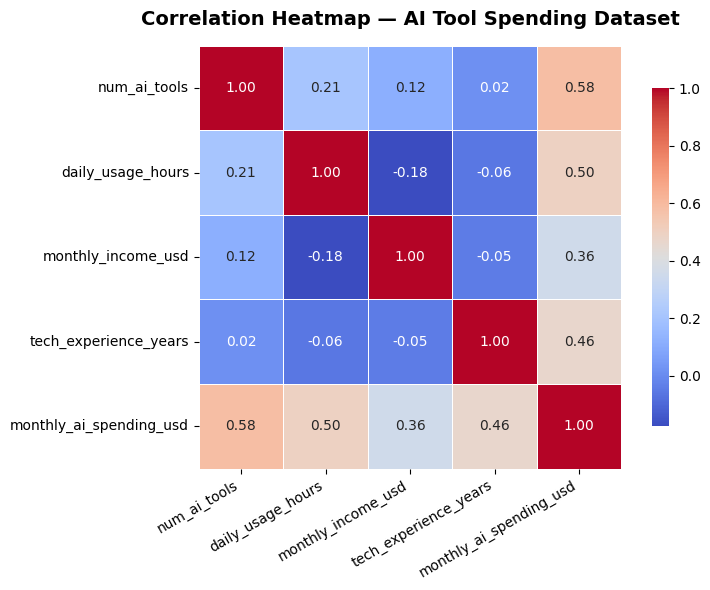


Correlation with monthly_ai_spending_usd:
monthly_ai_spending_usd    1.000000
num_ai_tools               0.582074
daily_usage_hours          0.497835
tech_experience_years      0.463015
monthly_income_usd         0.356561
Name: monthly_ai_spending_usd, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap — AI Tool Spending Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nCorrelation with monthly_ai_spending_usd:')
print(corr_matrix['monthly_ai_spending_usd'].sort_values(ascending=False))

**Why this step matters:** A correlation heatmap reveals how strongly each independent variable is linearly related to the dependent variable and to each other. High correlations between independent variables (multicollinearity) can distort model coefficients, while strong correlations with the target variable confirm which predictors are most useful for the model.

---
## Step 4: Fit the Dataset to the Multiple Linear Regression Model

In [ ]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

print('Model successfully fitted on training data.')
print(f'\nSample predictions vs actual values (first 10):')
results_df = pd.DataFrame({'Actual (USD)': y_test.values, 'Predicted (USD)': y_pred.round(2)})
print(results_df.reset_index(drop=True).to_string())

Model successfully fitted on training data.

Sample predictions vs actual values (first 10):
    Actual (USD)  Predicted (USD)
0         100.07           116.36
1         142.94           144.68
2         170.51           143.81
3         100.95            86.71
4         108.00           124.78
5         130.23           141.99
6         102.18            92.43
7         159.84           148.37
8         144.90           140.87
9          91.26            82.73
10         95.07           102.09
11        123.77           117.19


**Why this step matters:** Fitting the model means the algorithm learns the relationship between the independent variables and the target variable by finding the best-fit coefficients that minimize prediction error. This is the core step that produces the regression equation the model will use for predictions.

---
## Step 5: Extract and Interpret Model Intercept and Slope (Coefficients)

In [ ]:
print('═' * 55)
print('         MODEL PARAMETERS (MLR Equation)          ')
print('═' * 55)
print(f'  Intercept (β₀)          : $ {model.intercept_:.4f}')
print('─' * 55)
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature:<28}: {coef:.4f}')
print('═' * 55)

print('\n Regression Equation:')
eq = f'monthly_ai_spending = {model.intercept_:.2f}'
for feature, coef in zip(X.columns, model.coef_):
    sign = '+' if coef >= 0 else '-'
    eq += f' {sign} {abs(coef):.2f}×{feature}'
print(f'   {eq}')

═══════════════════════════════════════════════════════
         MODEL PARAMETERS (MLR Equation)          
═══════════════════════════════════════════════════════
  Intercept (β₀)          : $ -5.6117
───────────────────────────────────────────────────────
  num_ai_tools                : 4.6556
  daily_usage_hours           : 8.0055
  monthly_income_usd          : 0.0047
  tech_experience_years       : 2.4666
═══════════════════════════════════════════════════════

 Regression Equation:
   monthly_ai_spending = -5.61 + 4.66×num_ai_tools + 8.01×daily_usage_hours + 0.00×monthly_income_usd + 2.47×tech_experience_years


**Why this step matters:** The intercept represents the baseline predicted spending when all input variables are zero, while each coefficient (slope) tells us how much the monthly AI spending changes for every one-unit increase in that predictor, holding all other variables constant. Interpreting these values lets us understand the real-world impact each factor has on AI tool spending.

---
## Step 6: Evaluate Model Performance (MSE and R² Score)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_test, y_pred)

print('═' * 40)
print('       MODEL PERFORMANCE METRICS      ')
print('═' * 40)
print(f'  Mean Squared Error (MSE) : {mse:.4f}')
print(f'  Root MSE (RMSE)          : {rmse:.4f}')
print(f'  R² Score                 : {r2:.4f}')
print('═' * 40)

print(f'\nInterpretation:')
print(f'  The model explains {r2*100:.1f}% of the variance in monthly AI spending.')
print(f'  On average, predictions are off by ~${rmse:.2f} USD.')

════════════════════════════════════════
       MODEL PERFORMANCE METRICS      
════════════════════════════════════════
  Mean Squared Error (MSE) : 167.6700
  Root MSE (RMSE)          : 12.9487
  R² Score                 : 0.7485
════════════════════════════════════════

Interpretation:
  The model explains 74.8% of the variance in monthly AI spending.
  On average, predictions are off by ~$12.95 USD.


**Why this step matters:** MSE (Mean Squared Error) measures the average squared difference between actual and predicted values — lower is better. R² (coefficient of determination) tells us what proportion of variance in the dependent variable is explained by the model — closer to 1.0 means a stronger, more accurate model. Together, these metrics give an objective measure of model quality.

---
## Step 7: Display Actual vs. Predicted Values (Scatter Plot)

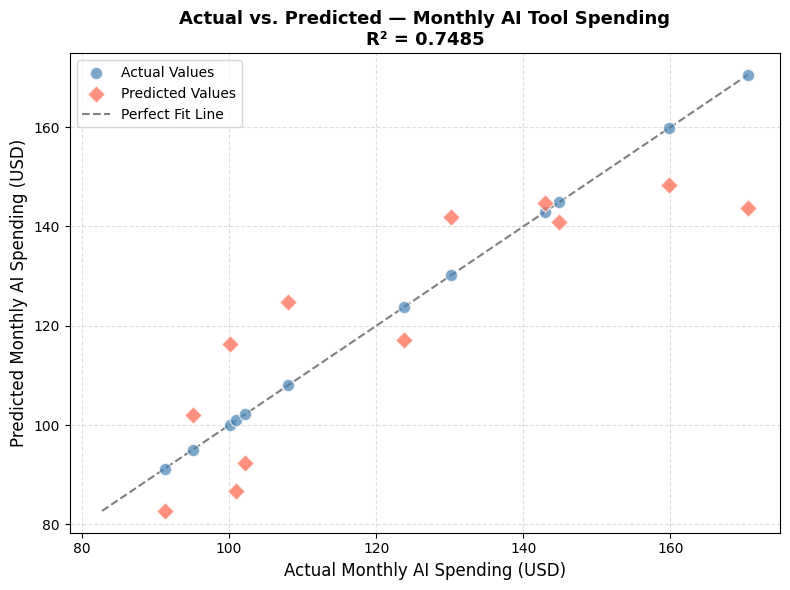

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter: actual values
ax.scatter(y_test, y_test,
           color='steelblue', alpha=0.7, edgecolors='white',
           s=80, label='Actual Values', zorder=3)

# Scatter: predicted values
ax.scatter(y_test, y_pred,
           color='tomato', alpha=0.7, edgecolors='white',
           s=80, marker='D', label='Predicted Values', zorder=3)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='gray', linestyle='--', linewidth=1.5,
        label='Perfect Fit Line', zorder=2)

ax.set_xlabel('Actual Monthly AI Spending (USD)', fontsize=12)
ax.set_ylabel('Predicted Monthly AI Spending (USD)', fontsize=12)
ax.set_title(
    f'Actual vs. Predicted — Monthly AI Tool Spending\nR² = {r2:.4f}',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Why this step matters:** Plotting actual versus predicted values gives a visual confirmation of model accuracy. When predicted values closely follow the perfect-fit diagonal line, the model is performing well. Outliers or systematic deviations in the plot indicate where the model may need improvement.

---
## Step 8: Test the Model — Interactive User Input

In [ ]:
print('=' * 55)
print('  AI TOOL SPENDING PREDICTOR — USER INPUT MODE   ')
print('=' * 55)

try:
    num_tools   = float(input('Enter number of AI tool subscriptions (1–10): '))
    usage_hrs   = float(input('Enter average daily usage hours (e.g., 2.5): '))
    income      = float(input('Enter monthly income in USD (e.g., 4000): '))
    experience  = float(input('Enter years of tech experience (e.g., 3): '))

    user_input = pd.DataFrame([{
        'num_ai_tools': num_tools,
        'daily_usage_hours': usage_hrs,
        'monthly_income_usd': income,
        'tech_experience_years': experience
    }])

    prediction = model.predict(user_input)[0]


    print('\n' + '─' * 55)
    print('   YOUR INPUTS:')
    print(f'     • AI tools subscribed    : {num_tools:.0f}')
    print(f'     • Daily usage hours      : {usage_hrs} hrs')
    print(f'     • Monthly income         : ${income:,.0f}')
    print(f'     • Tech experience        : {experience:.0f} years')
    print('─' * 55)
    print(f'   Predicted Monthly AI Spending: ${prediction:.2f} USD')
    print('─' * 55)

except ValueError:
    print(' Please enter valid numeric values.')

  AI TOOL SPENDING PREDICTOR — USER INPUT MODE   


**Why this step matters:** Testing the model with live user input demonstrates its practical usefulness. By entering real or hypothetical values, we can observe how the trained regression model responds to new, unseen data and produces a meaningful output — verifying that the model generalizes beyond the training set.